In [2]:
import pandas as pd
import numpy as np

df=pd.read_csv('../Data/payments_data_prepared.csv')
print(df.shape)
df.head()

(7043, 9)


,customerID,transaction_amount,customer_tenure_months,payment_method,retry_count,failure_reason,gateway_response_time_ms,customer_segment,payment_recovered
0,7590-VHVEG,358.2,1,Electronic check,0,insufficient_funds,272,new_customer,Yes
1,5575-GNVDE,683.4,34,Mailed check,3,bank_decline,544,high_value_repeat,Yes
2,3668-QPYBK,646.2,2,Mailed check,1,insufficient_funds,404,new_customer,No
3,7795-CFOCW,507.6,45,Bank transfer (automatic),1,network_error,2193,high_value_repeat,Yes
4,9237-HQITU,848.4,2,Electronic check,0,insufficient_funds,382,new_customer,No


In [3]:
df['payment_recovered'].value_counts(normalize=True)

payment_recovered
No     0.504615
Yes    0.495385
Name: proportion, dtype: float64

In [4]:
df['numeric_payment_recovered'] = df['payment_recovered'].map({'Yes': 1,'No':0})

In [5]:
df.columns.tolist()

['customerID',
 'transaction_amount',
 'customer_tenure_months',
 'payment_method',
 'retry_count',
 'failure_reason',
 'gateway_response_time_ms',
 'customer_segment',
 'payment_recovered',
 'numeric_payment_recovered']

In [6]:
recovery_by_reason=df.groupby('failure_reason')['numeric_payment_recovered'].mean()
print(recovery_by_reason)

failure_reason
bank_decline          0.534483
card_expired          0.071580
insufficient_funds    0.557037
network_error         0.835306
Name: numeric_payment_recovered, dtype: float64


In [7]:
import matplotlib.pyplot as plt

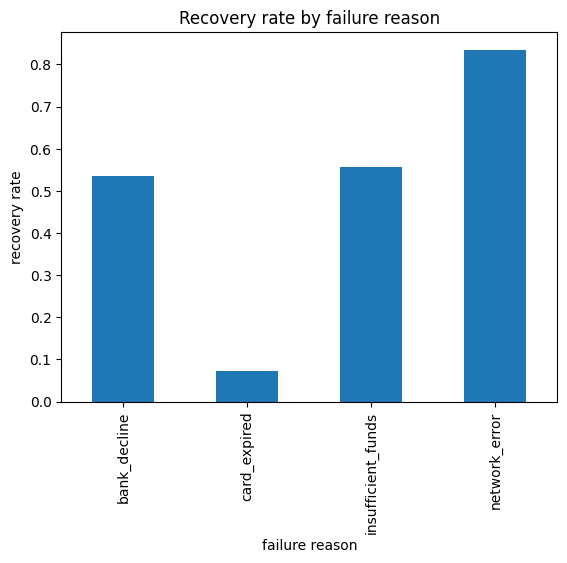

In [8]:
recovery_by_reason.plot(kind='bar')
plt.title("Recovery rate by failure reason")
plt.xlabel("failure reason")
plt.ylabel("recovery rate")
plt.show()

In [9]:
segment_reason=df.groupby('customer_segment')['numeric_payment_recovered'].mean()
print(segment_reason)

customer_segment
high_value_repeat    0.505087
new_customer         0.491525
occasional           0.479981
Name: numeric_payment_recovered, dtype: float64


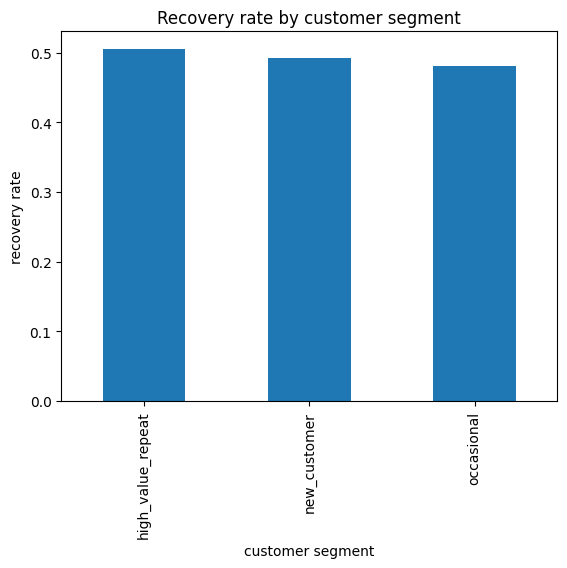

In [10]:
segment_reason.plot(kind='bar')
plt.title("Recovery rate by customer segment")
plt.xlabel("customer segment")
plt.ylabel("recovery rate")
plt.show()

In [11]:
payment_method_verification=df.groupby('payment_method')['numeric_payment_recovered'].mean()
print(payment_method_verification)

payment_method
Bank transfer (automatic)    0.483808
Credit card (automatic)      0.502628
Electronic check             0.504863
Mailed check                 0.485732
Name: numeric_payment_recovered, dtype: float64


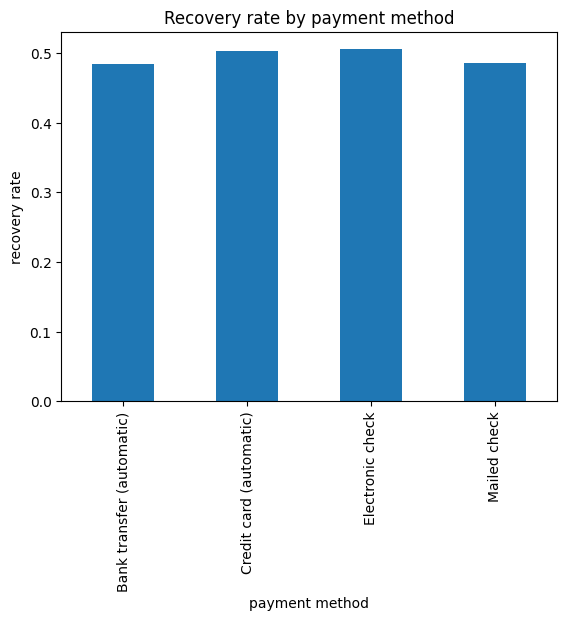

In [12]:
payment_method_verification.plot(kind='bar')
plt.title("Recovery rate by payment method")
plt.xlabel("payment method")
plt.ylabel("recovery rate")
plt.show()

In [13]:
retry_count_verification=df.groupby('retry_count')['numeric_payment_recovered'].mean()
print(retry_count_verification)

retry_count
0    0.551756
1    0.478093
2    0.454459
3    0.348201
Name: numeric_payment_recovered, dtype: float64


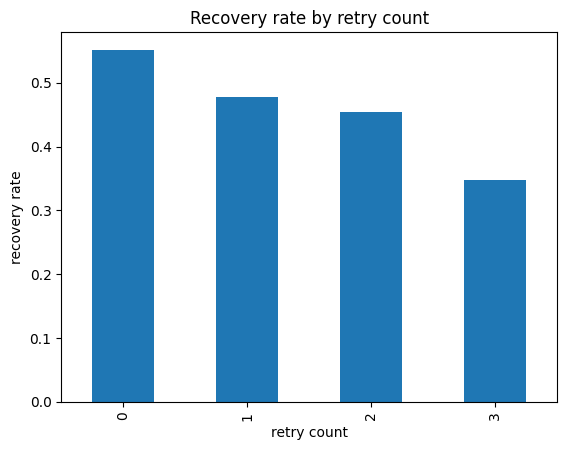

In [14]:
retry_count_verification.plot(kind='bar')
plt.title("Recovery rate by retry count")
plt.xlabel("retry count")
plt.ylabel("recovery rate")
plt.show()

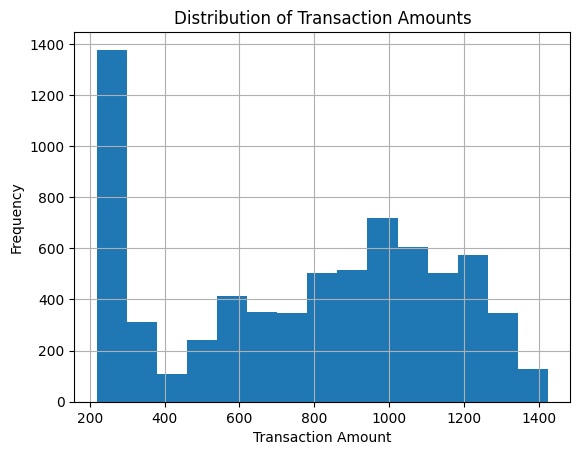

In [15]:
df['transaction_amount'].hist(bins=15)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()